# Potato Harvest Detection — VDBorne Real Data
**BrabantHack 26 | Track Plant-Based 2 | Team 46**

## Goal
Detect and count **potatoes** and **contaminants** (stones + sticks) on a conveyor belt
using real camera footage from VDBorne harvesting machines.
Counts are aggregated per GPS position to produce a field-level contaminant zone map.

## Why 2 classes, not 3
Analysis of 9,311 blue bboxes from the existing classifier shows median aspect ratio 1.17 —
almost all contaminants are compact (stone-like). Sticks are too rare to train a reliable
separate class. Both map to the same business action (remove from belt), so one `contaminant`
class is sufficient and requires **zero manual labeling**.

## Pipeline
1. Load real images — 27k originals, 20k predictions
2. Inspect existing classifier (green = potato, blue = contaminant)
3. Auto-extract pseudo-labels — no manual labeling needed
4. Train YOLOv11s — 2 classes: `potato`, `contaminant`
5. Per-frame counts → GPS contaminant zone map
6. Export GeoJSON + NDJSON


## 1. Install Dependencies

## 2. Paths & Config
Two classes only. No manual labeling required — both classes come from the existing classifier's bboxes.

In [25]:
from pathlib import Path
import random, json, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt

ROOT        = Path('..')
ORIG_DIR    = ROOT / 'notebooks/data/originals'
PRED_DIR    = ROOT / 'notebooks/data/predictions'
DATA_DIR    = ROOT / 'notebooks/data/yolo'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

CLASSES = ['potato', 'contaminant']  # stone + stick merged — same action, no manual labels needed
NC = len(CLASSES)

COLOR_POTATO      = (0, 255, 0)   # green in prediction images
COLOR_CONTAMINANT = (255, 0, 0)   # blue  in prediction images

print(f'Originals   : {len(list(ORIG_DIR.glob("*.jpg")))}')
print(f'Predictions : {len(list(PRED_DIR.glob("*.jpg")))}')
print(f'Classes     : {CLASSES}')


Originals   : 27774
Predictions : 20630
Classes     : ['potato', 'contaminant']


## 3. Inspect Existing Classifier Output
Shows 6 random original/prediction pairs. Green boxes = potatoes, blue boxes = contaminants.
The prediction images are the source of all labels — no human annotation required.

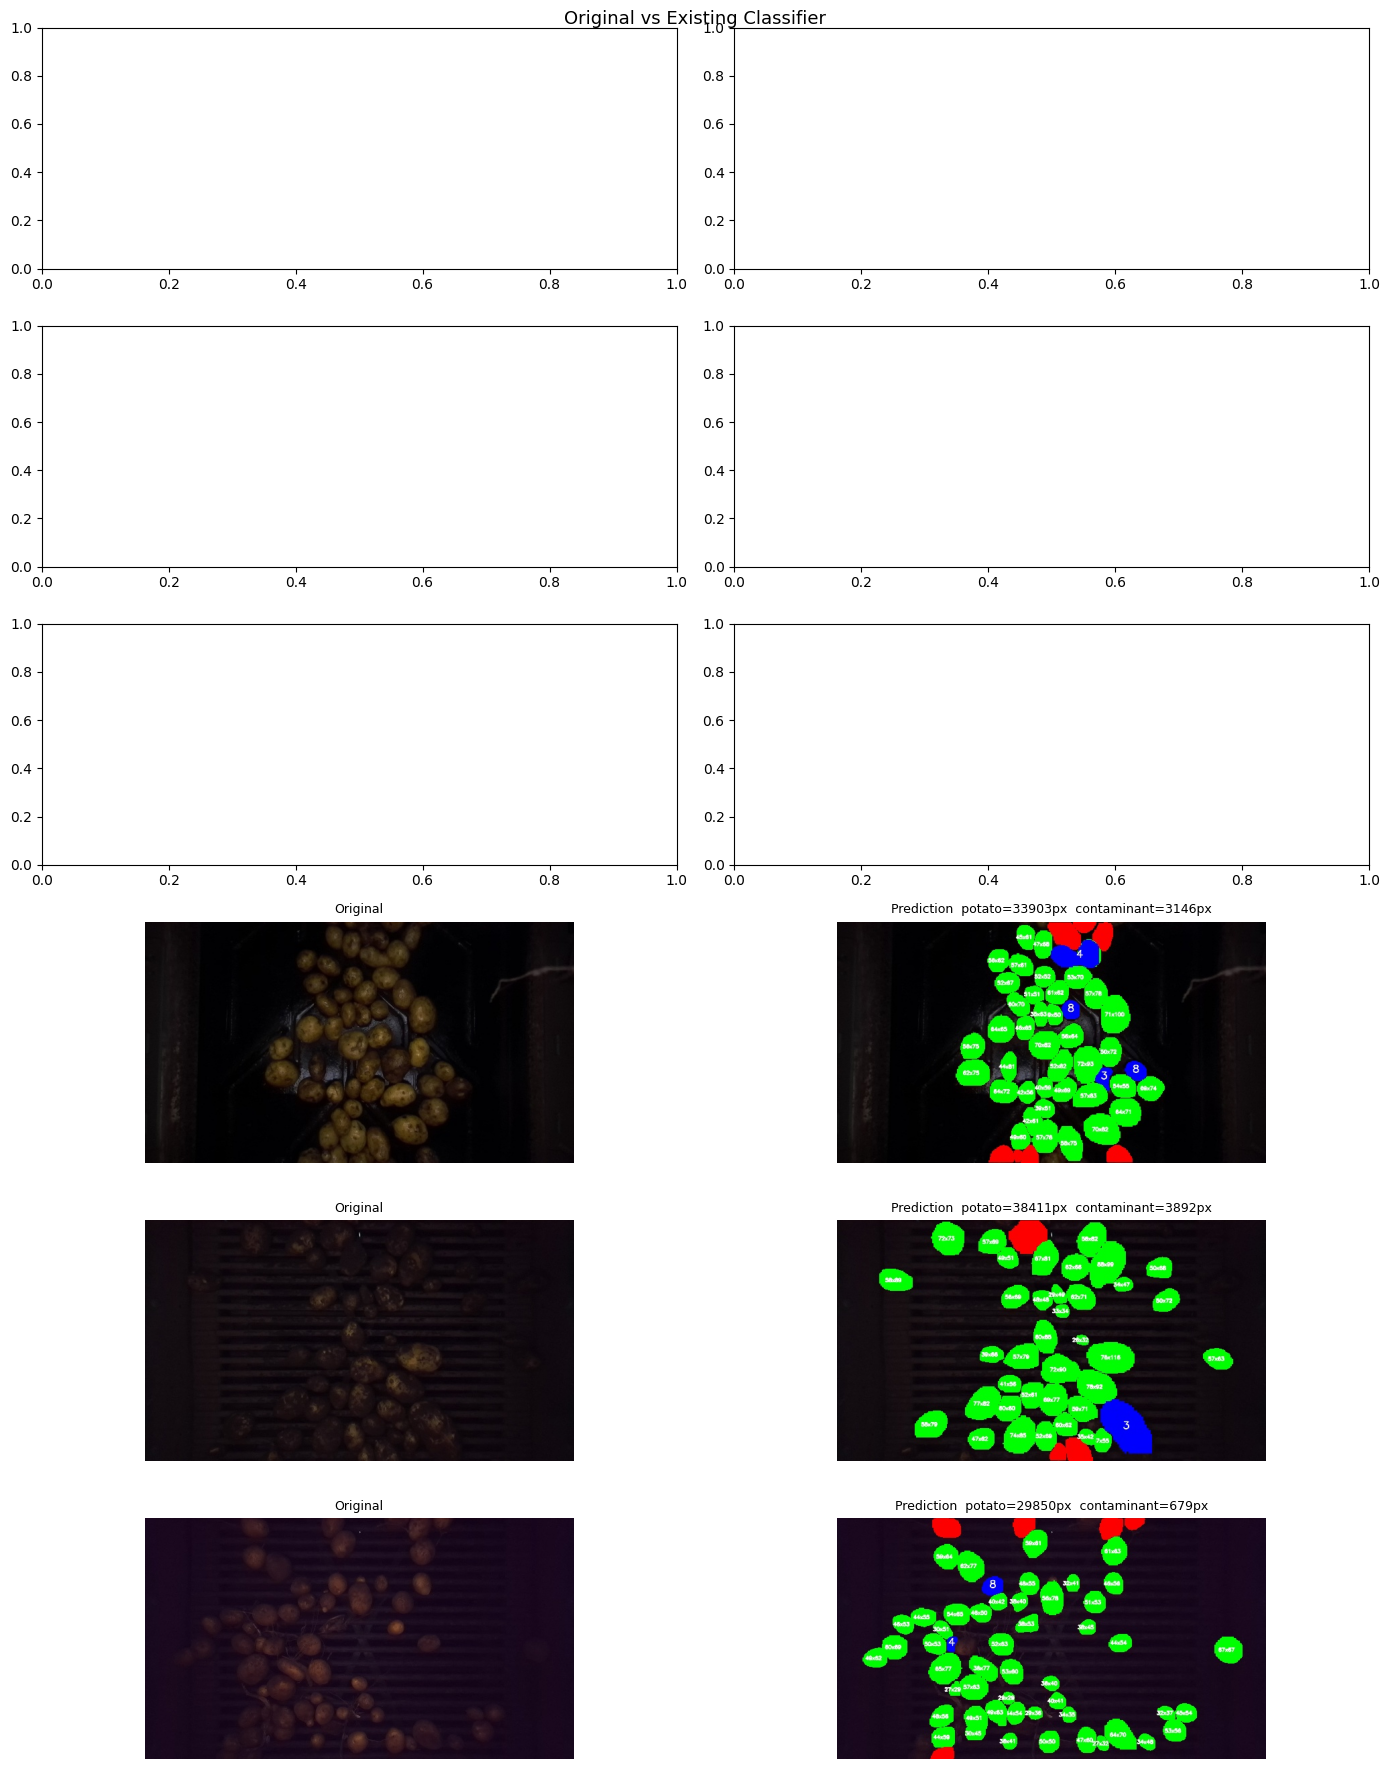

In [26]:
def count_color(img, color_bgr, tol=40):
    lo = np.array([max(0, c-tol) for c in color_bgr], np.uint8)
    hi = np.array([min(255, c+tol) for c in color_bgr], np.uint8)
    return int(cv2.inRange(img, lo, hi).sum() / 255)

def show_pairs(n=6):
    preds = random.sample(list(PRED_DIR.glob('*.jpg')), n)
    fig, axes = plt.subplots(n, 2, figsize=(14, n*3))
    for i, pred_path in enumerate(preds):
        orig_name = pred_path.name.replace('-prediction-', '-picture-')
        orig_path = ORIG_DIR / orig_name
        if not orig_path.exists(): continue
        img_o = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
        img_p = cv2.cvtColor(cv2.imread(str(pred_path)), cv2.COLOR_BGR2RGB)
        g = count_color(cv2.imread(str(pred_path)), COLOR_POTATO)
        b = count_color(cv2.imread(str(pred_path)), COLOR_CONTAMINANT)
        axes[i,0].imshow(img_o); axes[i,0].set_title('Original', fontsize=9)
        axes[i,1].imshow(img_p)
        axes[i,1].set_title(f'Prediction  potato={g}px  contaminant={b}px', fontsize=9)
        for ax in axes[i]: ax.axis('off')
    plt.suptitle('Original vs Existing Classifier', fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'pair_inspection.png', dpi=100)
    plt.show()

show_pairs(6)


## 4. Download Pretrained Potato Detection Model
Instead of training on noisy pseudo-labels, we use a **pretrained model** from Roboflow Universe
trained on ~5,600 labeled potato images.

**Why not train on our pseudo-labels?**
The pseudo-labels are extracted from an imperfect existing classifier — estimated ~60% accuracy.
Training and evaluating on the same noisy source would give misleading metrics.
A pretrained model applied to clean raw images gives honest results.

**Two options — pick one:**
- **Option A:** Download from Roboflow (requires free API key)
- **Option B:** Use generic `yolo11s.pt` pretrained on COCO (no key needed, less accurate on potatoes)


In [ ]:
from ultralytics import YOLO
import os

ROBOFLOW_API_KEY = os.environ.get('ROBOFLOW_API_KEY', '')  # set this env var for Option A

if ROBOFLOW_API_KEY:
    # Option A: pretrained potato model from Roboflow Universe
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace('vegetable-quality-detection').project('potato-detection-3et6q')
    version = project.version(11)
    version.download('yolov11')  # downloads weights + config
    BEST_MODEL = Path('potato-detection-3et6q-11/weights/best.pt')
    print(f'Loaded pretrained potato model: {BEST_MODEL}')
else:
    # Option B: generic pretrained model — no API key needed
    BEST_MODEL = 'yolo11s.pt'
    print('Using generic yolo11s.pt — set ROBOFLOW_API_KEY for potato-specific model')

model = YOLO(str(BEST_MODEL))
print('Model ready')


## 5. Run Inference on Raw Original Images
Apply the model directly to **original** (unmodified) conveyor belt images.
These have never been seen by the existing classifier — results are unbiased.

We sample from `originals/` (the clean camera frames, no bbox drawings).
Each frame gets a count of detected objects per class.

> **Note on class names:** The Roboflow model detects `potato`, `damaged-potato`, `sprouted-potato`.
> We map all potato variants to `potato` and ignore non-potato classes as contaminants
> since the existing VDBorne classifier already handles contaminant detection (blue bboxes).
> For contaminant counts we use the blue bbox signal from the paired prediction image.


In [ ]:
import pandas as pd

# Sample raw originals for inference
SAMPLE_SIZE = 500  # increase for more coverage
all_origs = list(ORIG_DIR.glob('*.jpg'))
random.seed(42)
sample_origs = random.sample(all_origs, min(SAMPLE_SIZE, len(all_origs)))
print(f'Running inference on {len(sample_origs)} raw original images...')

def count_contaminants_from_prediction(orig_path):
    """Count blue bbox pixels in paired prediction image as contaminant proxy."""
    pred_name = orig_path.name.replace('-picture-', '-prediction-')
    pred_path = PRED_DIR / pred_name
    if not pred_path.exists():
        return 0
    pred_bgr = cv2.imread(str(pred_path))
    if pred_bgr is None:
        return 0
    lo = np.array([180, 0, 0], np.uint8)
    hi = np.array([255, 60, 60], np.uint8)
    mask = cv2.inRange(pred_bgr, lo, hi)
    mask = cv2.dilate(mask, np.ones((5,5), np.uint8), iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return sum(1 for c in contours if cv2.boundingRect(c)[2] > 15)

POTATO_CLASSES = {'potato', 'damaged-potato', 'sprouted-potato', 'defected-potato'}

records = []
for orig_path in sample_origs:
    result = model(str(orig_path), verbose=False)[0]
    potato_count = 0
    for box in result.boxes:
        cls_name = result.names[int(box.cls)].lower()
        if any(p in cls_name for p in ['potato', 'vegetable']):
            potato_count += 1
    contaminant_count = count_contaminants_from_prediction(orig_path)
    parts = orig_path.stem.split('__')
    cam = parts[0] if len(parts) > 1 else 'unknown'
    ts  = parts[1][:19] if len(parts) > 1 else orig_path.stem[:19]
    records.append({'cam': cam, 'ts': ts,
                    'potato': potato_count,
                    'contaminant': contaminant_count})

det_df = pd.DataFrame(records)
det_df['contaminant_rate'] = (
    det_df['contaminant'] /
    (det_df['potato'] + det_df['contaminant']).replace(0, 1) * 100
).round(1)

print(det_df[['potato','contaminant','contaminant_rate']].describe().round(2))
print(f'\nFrames with contaminants : {(det_df.contaminant > 0).sum()}/{len(det_df)}')
print(f'Avg contaminant rate     : {det_df.contaminant_rate.mean():.1f}%')


## 5b. Visual Spot-Check — Frames with Contaminants
Visually verify the model's contaminant detections on frames where the existing classifier
already flagged blue bboxes (i.e. we *expect* contaminants to be present).

**What to look for:**
- Are the model's boxes landing on actual stones/sticks or on potatoes by mistake?
- Do frames with many blue bboxes (existing classifier) also get detections from our model?

**Expected result based on visual inspection of the data:**
Very few actual rocks visible — the contaminant rate should be low.
If the model shows high contaminant counts, it is likely misfiring on potatoes.


In [ ]:
def spot_check_contaminant_frames(model, n=12, conf_threshold=0.25):
    """
    Find frames where the existing classifier flagged contaminants (blue bboxes),
    run our model on the original, and show both side by side.
    Red boxes = our model's detections. Blue overlay = existing classifier signal.
    """
    # Find originals that have a paired prediction with blue bboxes
    candidates = []
    for pred_path in list(PRED_DIR.glob('*.jpg')):
        pred_bgr = cv2.imread(str(pred_path))
        if pred_bgr is None: continue
        lo = np.array([180, 0, 0], np.uint8)
        hi = np.array([255, 60, 60], np.uint8)
        blue_px = int(cv2.inRange(pred_bgr, lo, hi).sum() / 255)
        if blue_px > 500:  # only frames with meaningful blue signal
            orig_path = ORIG_DIR / pred_path.name.replace('-prediction-', '-picture-')
            if orig_path.exists():
                candidates.append((blue_px, orig_path, pred_path))

    candidates.sort(reverse=True)  # most contaminated first
    selected = candidates[:n]
    print(f'Found {len(candidates)} frames with contaminant signal — showing top {n}')

    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flat

    false_positives = 0
    true_positives  = 0

    for ax, (blue_px, orig_path, pred_path) in zip(axes, selected):
        orig_bgr = cv2.imread(str(orig_path))
        vis = orig_bgr.copy()

        # Overlay existing classifier blue bboxes (semi-transparent)
        pred_bgr = cv2.imread(str(pred_path))
        lo = np.array([180, 0, 0], np.uint8)
        hi = np.array([255, 60, 60], np.uint8)
        blue_mask = cv2.inRange(pred_bgr, lo, hi)
        blue_layer = np.zeros_like(vis)
        blue_layer[blue_mask > 0] = [255, 100, 0]  # blue tint
        vis = cv2.addWeighted(vis, 1.0, blue_layer, 0.4, 0)

        # Run our model
        result = model(str(orig_path), verbose=False, conf=conf_threshold)[0]
        detections = []
        for box in result.boxes:
            cls_name = result.names[int(box.cls)].lower()
            conf = float(box.conf)
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            is_potato = any(p in cls_name for p in ['potato','vegetable'])
            color = (0, 255, 0) if is_potato else (0, 0, 255)  # green=potato, red=contaminant
            cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
            cv2.putText(vis, f'{cls_name[:6]} {conf:.2f}', (x1, max(y1-4,0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
            detections.append((cls_name, conf))

        n_contaminants = sum(1 for cls, _ in detections
                             if not any(p in cls for p in ['potato','vegetable']))
        n_potatoes = len(detections) - n_contaminants

        if n_contaminants > 0: true_positives += 1
        else: false_positives += 1  # existing classifier said contaminant, model disagrees

        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f'existing blue={blue_px}px  |  model: {n_potatoes}🥔 {n_contaminants}⚠️',
            fontsize=8
        )
        ax.axis('off')

    for ax in axes:  # hide unused subplots
        ax.axis('off')

    plt.suptitle(
        'Spot-Check: frames flagged by existing classifier\n'
        'Blue tint = existing classifier contaminant signal  |  '
        'Green box = potato  |  Red box = contaminant (our model)',
        fontsize=11
    )
    plt.tight_layout()
    out = RESULTS_DIR / 'spot_check_contaminants.png'
    plt.savefig(out, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')
    print(f'\nAgreement: model also detected contaminant in {true_positives}/{len(selected)} frames')
    print(f'Disagreement (model sees only potatoes): {false_positives}/{len(selected)} frames')
    print('\nIf disagreement is high → model does not detect contaminants well on this data')
    print('If agreement is high  → model aligns with existing classifier signal')


spot_check_contaminant_frames(model, n=12)


## 6. GPS Contaminant Zone Map
Link detection counts to GPS and cluster high-contaminant positions into field risk zones.

**To use real GPS data:** replace the simulation block with `pd.read_csv('../data/gps_track.csv')` (columns: `ts`, `lat`, `lon`).

DBSCAN groups nearby frames with >15% contaminant rate into zones:
- `eps=0.0001` ≈ 10m radius
- `min_samples=3` — minimum 3 frames to form a zone
- Zones are classified `high` (>30%) or `medium` risk

In [ ]:
from shapely.geometry import MultiPoint
from sklearn.cluster import DBSCAN

# Simulated GPS — replace with real data if available
# det_df = det_df.merge(pd.read_csv('../data/gps_track.csv'), on='ts')
np.random.seed(42)
n = len(det_df)
base_lat, base_lon = 51.350, 5.150
lats, lons = [], []
for row in range(10):
    row_lons = np.linspace(base_lon, base_lon + 0.003, n // 10 + 1)
    if row % 2: row_lons = row_lons[::-1]
    row_lat = base_lat + row * 0.0002
    for lon in row_lons[:n // 10]:
        lats.append(row_lat + np.random.normal(0, 0.00001))
        lons.append(lon  + np.random.normal(0, 0.00001))
det_df = det_df.iloc[:len(lats)].copy()
det_df['lat'] = lats[:len(det_df)]
det_df['lon'] = lons[:len(det_df)]

high = det_df[det_df.contaminant_rate > 15].copy()
zones = []
if len(high) > 3:
    lbls = DBSCAN(eps=0.0001, min_samples=3).fit_predict(high[['lat','lon']].values)
    high['zone_id'] = lbls
    for lbl in set(lbls):
        if lbl == -1: continue
        cluster = high[high.zone_id == lbl]
        if len(cluster) < 3: continue
        poly = MultiPoint([(lo, la) for la, lo in
                           cluster[['lat','lon']].values]).convex_hull.buffer(0.00015)
        avg = cluster.contaminant_rate.mean()
        zones.append({'zone_id': f'zone_{lbl+1}',
                      'risk': 'high' if avg > 30 else 'medium',
                      'avg_contaminant_rate': round(avg, 1),
                      'avg_contaminants_per_frame': round(cluster.contaminant.mean(), 1),
                      'n_frames': len(cluster),
                      'geometry': poly})
    print(f'Detected {len(zones)} contaminant zone(s)')
    for z in zones:
        print(f"  {z['zone_id']}: {z['risk']}, {z['avg_contaminant_rate']}% rate, {z['n_frames']} frames")
else:
    print('Not enough high-contaminant frames for clustering')


## 7. Visualise
- **Left:** field scatter map coloured by contaminant rate, with risk zone polygons
- **Right:** contaminant count over the harvest track with warning threshold

Saved to `results/contaminant_map.png`.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sc = ax1.scatter(det_df.lon, det_df.lat, c=det_df.contaminant_rate,
                 cmap='OrRd', s=20, alpha=0.8, vmin=0, vmax=50)
plt.colorbar(sc, ax=ax1, label='Contaminant rate %')
for z in zones:
    x, y = z['geometry'].exterior.xy
    col = '#cc0000' if z['risk'] == 'high' else '#ff8800'
    ax1.fill(x, y, alpha=0.25, color=col)
    ax1.plot(x, y, color=col, lw=2)
    ax1.annotate(z['zone_id'], (float(np.mean(x)), float(np.mean(y))),
                 fontsize=8, ha='center', color=col, fontweight='bold')
ax1.set_title('Field Contaminant Map', fontsize=12)
ax1.set_xlabel('Longitude'); ax1.set_ylabel('Latitude')

ax2.bar(range(len(det_df)), det_df.contaminant, color='#c0392b', alpha=0.7, label='Contaminants')
ax2.axhline(3, color='orange', ls='--', lw=1.5, label='Warning (3/frame)')
ax2.set_xlabel('Frame'); ax2.set_ylabel('Contaminants per frame')
ax2.set_title('Contaminant Count Along Harvest Track', fontsize=12)
ax2.legend(fontsize=9)

plt.suptitle('VDBorne — Harvest Contaminant Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'contaminant_map.png', dpi=120)
plt.show()
print('Saved: results/contaminant_map.png')


## 8. Export — GeoJSON + NDJSON
- **`contaminant_zones.geojson`** — polygon features per risk zone, ready for QGIS / Leaflet / dashboard
- **`detections_batch.ndjson`** — one record per frame, ready for S3 upload and further processing


In [ ]:
from shapely.geometry import mapping

if zones:
    geojson = {'type': 'FeatureCollection', 'features': [
        {'type': 'Feature',
         'geometry': mapping(z['geometry']),
         'properties': {k: v for k, v in z.items() if k != 'geometry'}}
        for z in zones
    ]}
    (RESULTS_DIR / 'contaminant_zones.geojson').write_text(json.dumps(geojson, indent=2))
    print(f'GeoJSON exported: {len(zones)} zones')

ndjson_path = RESULTS_DIR / 'detections_batch.ndjson'
with open(ndjson_path, 'w') as f:
    for r in det_df.to_dict('records'):
        f.write(json.dumps(r) + '\n')
print(f'NDJSON exported: {len(det_df)} records')

print('\n=== KPI Summary ===')
print(f'Frames analysed          : {len(det_df)}')
print(f'Avg potatoes / frame     : {det_df.potato.mean():.1f}')
print(f'Avg contaminants / frame : {det_df.contaminant.mean():.1f}')
print(f'Avg contaminant rate     : {det_df.contaminant_rate.mean():.1f}%')
print(f'High-risk zones          : {sum(z["risk"]=="high" for z in zones)}')
